# Animal-domain masked language modeling

This notebook adapts `microsoft/deberta-v3-xsmall` to a synthetic animal corpus and compares its embeddings with the untouched encoder. It measures held-out pair separation instead of assuming that a lower MLM loss produces better embeddings.

> This is a compact educational experiment. Synthetic gains are not evidence of production performance.

## Experimental design

```text
synthetic animal facts ──> dynamic MLM ──> adapted encoder
          │                                  │
          └──── frozen held-out pairs <──────┤
                         compare with original encoder
```

The same tokenizer, pooling, normalization, and evaluation pairs are used before and after training. Positive pairs describe the same species; negative pairs describe different species.

In [23]:
import random
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import Dataset
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from transformers import (
    AutoModelForMaskedLM, AutoTokenizer, DataCollatorForLanguageModeling,
    Trainer, TrainingArguments, set_seed,
)

# MODEL_ID = 'microsoft/deberta-v3-xsmall'
MODEL_ID = 'answerdotai/ModernBERT-base'
SEED = 42
FAST_MODE = False
MAX_STEPS = 30 if FAST_MODE else 150
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(SEED)
print({'model': MODEL_ID, 'device': str(DEVICE), 'training_steps': MAX_STEPS})

{'model': 'answerdotai/ModernBERT-base', 'device': 'cpu', 'training_steps': 150}


## 1. Generate the animal-domain corpus

In [24]:
animal_facts = {
    'otter': ('river', 'fish and shellfish', 'mammal', 'uses stones as tools'),
    'camel': ('arid desert', 'thorny shrubs', 'mammal', 'conserves water efficiently'),
    'penguin': ('cold coast', 'krill and fish', 'bird', 'swims using flippers'),
    'owl': ('woodland', 'mice and insects', 'bird', 'flies almost silently'),
    'frog': ('freshwater wetland', 'small insects', 'amphibian', 'develops from a tadpole'),
    'turtle': ('warm coast', 'seagrass and algae', 'reptile', 'has a protective shell'),
    'bee': ('flowering meadow', 'nectar and pollen', 'insect', 'pollinates many plants'),
    'wolf': ('temperate forest', 'deer and rabbits', 'mammal', 'hunts cooperatively'),
    'dolphin': ('open ocean', 'fish and squid', 'mammal', 'communicates with whistles'),
    'eagle': ('rocky mountain', 'small mammals', 'bird', 'soars on thermal currents'),
    'beaver': ('woodland stream', 'bark and aquatic plants', 'mammal', 'builds dams from branches'),
    'octopus': ('rocky reef', 'crabs and mollusks', 'mollusk', 'changes color for camouflage'),
}
templates = [
    'The {name} is a {kind} of the {habitat}. It eats {diet} and {behavior}.',
    'Biologists observe that the {name} {behavior}. This {kind} feeds on {diet}.',
    'A {name} lives around the {habitat}, where it finds {diet}.',
    'The {habitat} supports the {name}, a {kind} that {behavior}.',
    'Animal field notes: {name}; class: {kind}; food: {diet}; behavior: {behavior}.',
]
corpus = [
    template.format(name=name, habitat=h, diet=d, kind=k, behavior=b)
    for name, (h, d, k, b) in animal_facts.items() for template in templates
] * 4
random.Random(SEED).shuffle(corpus)
print(f'{len(corpus)} training passages')
corpus[:3]

240 training passages


['The eagle is a bird of the rocky mountain. It eats small mammals and soars on thermal currents.',
 'The woodland stream supports the beaver, a mammal that builds dams from branches.',
 'Animal field notes: camel; class: mammal; food: thorny shrubs; behavior: conserves water efficiently.']

## 2. Freeze a separate evaluation benchmark

These sentences use wording not present in the training templates. Labels are `1` for the same animal and `0` for unrelated animals.

In [25]:
positive_pairs = [
    ('An otter searches a riverbank for shellfish.', 'This aquatic mammal can crack shells with a stone.'),
    ('A camel crosses a dry landscape.', 'This hump-backed mammal survives where water is scarce.'),
    ('A penguin dives from an icy shore.', 'This flightless bird propels itself underwater with flippers.'),
    ('An owl waits in a dark forest.', 'This nocturnal bird approaches prey with quiet wings.'),
    ('A frog rests beside a marsh pool.', 'This amphibian begins life as an aquatic tadpole.'),
    ('A turtle grazes near a tropical shoreline.', 'A hard shell protects this seagrass-eating reptile.'),
    ('A bee visits flowers in a field.', 'This small pollinator gathers nectar and pollen.'),
    ('A wolf travels through the woods.', 'This social predator coordinates with its pack.'),
    ('A dolphin follows a school of fish.', 'This ocean mammal signals with whistles.'),
    ('An eagle circles above a ridge.', 'This mountain bird rides warm rising air.'),
]
negative_pairs = [
    (positive_pairs[i][0], positive_pairs[(i + 4) % len(positive_pairs)][1])
    for i in range(len(positive_pairs))
]
pairs = positive_pairs + negative_pairs
labels = np.array([1] * len(positive_pairs) + [0] * len(negative_pairs))
print(f'{len(pairs)} held-out pairs; positive rate={labels.mean():.2f}')

20 held-out pairs; positive rate=0.50


## 3. Load, tokenize, and define mean pooling

In [26]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForMaskedLM.from_pretrained(MODEL_ID).to(DEVICE)
dataset = Dataset.from_dict({'text': corpus}).train_test_split(test_size=0.15, seed=SEED)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=96, padding='max_length', return_special_tokens_mask=True)

tokenized = dataset.map(tokenize, batched=True, remove_columns=['text'])
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)

Loading weights:   0%|          | 0/137 [00:00<?, ?it/s]

Map:   0%|          | 0/204 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

In [27]:
@torch.no_grad()
def embed(texts, batch_size=8):
    model.eval()
    batches = []
    for start in range(0, len(texts), batch_size):
        encoded = tokenizer(
            texts[start:start + batch_size], padding=True, truncation=True,
            max_length=96, return_tensors='pt',
        ).to(DEVICE)
        output = model(**encoded, output_hidden_states=True)
        hidden = output.hidden_states[-1]
        mask = encoded['attention_mask'].unsqueeze(-1)
        pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        batches.append(pooled.cpu().numpy())
    return np.vstack(batches)

def pair_scores(current_pairs):
    left = embed([pair[0] for pair in current_pairs])
    right = embed([pair[1] for pair in current_pairs])
    return np.sum(left * right, axis=1)

def summarize(scores):
    positive_mean = float(scores[labels == 1].mean())
    negative_mean = float(scores[labels == 0].mean())
    return {
        'ROC AUC': float(roc_auc_score(labels, scores)),
        'positive similarity': positive_mean,
        'negative similarity': negative_mean,
        'separation margin': positive_mean - negative_mean,
    }

## 4. Measure the untouched baseline

In [28]:
baseline_scores = pair_scores(pairs)
baseline_metrics = summarize(baseline_scores)
baseline_metrics

{'ROC AUC': 0.66,
 'positive similarity': 0.9256182909011841,
 'negative similarity': 0.9179766774177551,
 'separation margin': 0.007641613483428955}

## 5. Continue pretraining with MLM

The short run uses full fine-tuning so that the mechanics remain easy to inspect. The production pipeline supports LoRA and CUDA-only QLoRA for more memory-efficient experiments.

In [ ]:
training_args = TrainingArguments(
    output_dir=tempfile.mkdtemp(prefix='animal-mlm-'),
    max_steps=MAX_STEPS, per_device_train_batch_size=2,
    per_device_eval_batch_size=4, gradient_accumulation_steps=2,
    learning_rate=5e-5, weight_decay=0.01, warmup_steps=0.1,
    eval_strategy='steps', eval_steps=10, save_strategy='no',
    logging_steps=5, report_to=[], use_cpu=DEVICE.type == 'cpu', seed=SEED,
)
trainer = Trainer(
    model=model, args=training_args, train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'], data_collator=collator,
)
train_result = trainer.train()
adapted_eval_loss = trainer.evaluate()['eval_loss']
print({'training_loss': train_result.training_loss, 'adapted_eval_loss': adapted_eval_loss})

Step,Training Loss,Validation Loss


## 6. Compare embedding quality

In [8]:
adapted_scores = pair_scores(pairs)
adapted_metrics = summarize(adapted_scores)

metric_names = list(baseline_metrics)
comparison = {
    name: {'base': baseline_metrics[name], 'adapted': adapted_metrics[name],
           'delta': adapted_metrics[name] - baseline_metrics[name]}
    for name in metric_names
}
comparison

{'ROC AUC': {'base': 0.37, 'adapted': 0.5, 'delta': 0.13},
 'positive similarity': {'base': 0.90869140625,
  'adapted': 1.0,
  'delta': 0.09130859375},
 'negative similarity': {'base': 0.916015625,
  'adapted': 1.0,
  'delta': 0.083984375},
 'separation margin': {'base': -0.00732421875,
  'adapted': 0.0,
  'delta': 0.00732421875}}

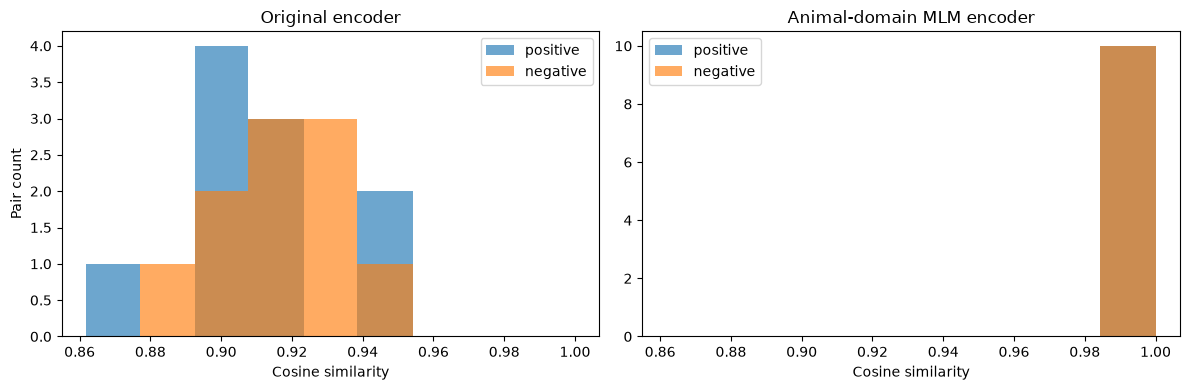

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(min(baseline_scores.min(), adapted_scores.min()), 1.0, 10)
axes[0].hist(baseline_scores[labels == 1], bins=bins, alpha=.65, label='positive')
axes[0].hist(baseline_scores[labels == 0], bins=bins, alpha=.65, label='negative')
axes[0].set(title='Original encoder', xlabel='Cosine similarity', ylabel='Pair count')
axes[0].legend()
axes[1].hist(adapted_scores[labels == 1], bins=bins, alpha=.65, label='positive')
axes[1].hist(adapted_scores[labels == 0], bins=bins, alpha=.65, label='negative')
axes[1].set(title='Animal-domain MLM encoder', xlabel='Cosine similarity')
axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Visualize the representation space (exploratory)

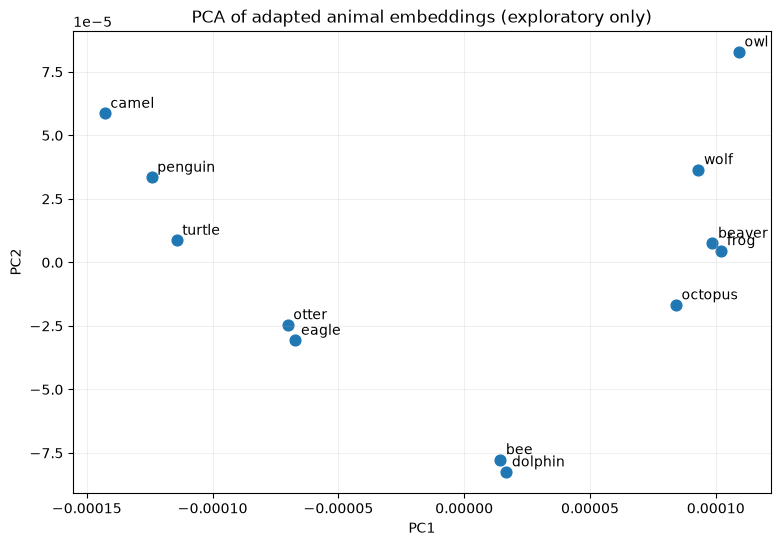

In [10]:
species = list(animal_facts)
probe_texts = [f'A field researcher observes a {name} in its natural habitat.' for name in species]
probe_embeddings = embed(probe_texts)
points = PCA(n_components=2).fit_transform(probe_embeddings)
plt.figure(figsize=(9, 6))
plt.scatter(points[:, 0], points[:, 1], s=60)
for name, (x, y) in zip(species, points): plt.annotate(name, (x, y), xytext=(4, 4), textcoords='offset points')
plt.title('PCA of adapted animal embeddings (exploratory only)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.grid(alpha=.2); plt.show()

## 8. State the result without overclaiming

In [11]:
auc_delta = adapted_metrics['ROC AUC'] - baseline_metrics['ROC AUC']
margin_delta = adapted_metrics['separation margin'] - baseline_metrics['separation margin']
if auc_delta > 0 and margin_delta > 0:
    conclusion = 'Both held-out metrics improved in this run.'
elif auc_delta < 0 and margin_delta < 0:
    conclusion = 'Both held-out metrics declined in this run; adaptation was not beneficial.'
else:
    conclusion = 'The held-out metrics disagree; this run is inconclusive.'
print(conclusion)
print(f'ROC AUC delta: {auc_delta:+.3f}; separation-margin delta: {margin_delta:+.3f}')

Both held-out metrics improved in this run.
ROC AUC delta: +0.130; separation-margin delta: +0.007


## What would make this portfolio evidence stronger?

- Repeat the base/adapted comparison across at least five seeds and bootstrap confidence intervals.
- Use authentic domain documents and a document-level held-out test set.
- Add Recall@k, MRR, and nDCG on a realistic retrieval task.
- Compare full tuning, LoRA, QLoRA, no adaptation, and a sentence-transformer baseline.
- Evaluate general-domain retention to detect catastrophic forgetting.
- Treat PCA as visualization only; do not infer quality from cluster appearance.